In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install shap xgboost imbalanced-learn

In [5]:
import pandas as pd

path = "/content/drive/MyDrive/JIT_bug_prediction/data/apachejit.csv"

df = pd.read_csv(path)

df.head()

,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,False,2003,1070355653,372,23,8,3,3,2.669743,0.250000,3.625000,2.125,243,243.0,0.683585
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,False,2003,1063298262,2,2,2,2,1,1.000000,1.000000,0.000000,2.500,19,19.0,14.000000
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,False,2003,1069704572,41,26,3,3,2,1.237612,0.666667,5.333333,45.000,233,233.0,0.000606
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,False,2003,1068487625,8,6,2,1,1,0.591673,1.000000,3.000000,35.500,64,64.0,55.000000
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,False,2003,1063313516,70,4,6,3,1,2.519672,0.333333,0.000000,6.000,27,27.0,22.000000


In [6]:
df.shape

(106674, 18)

In [7]:
df.columns

Index(['commit_id', 'project', 'buggy', 'fix', 'year', 'author_date', 'la',
       'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp',
       'asexp'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   commit_id    106674 non-null  object 
 1   project      106674 non-null  object 
 2   buggy        106674 non-null  bool   
 3   fix          106674 non-null  bool   
 4   year         106674 non-null  int64  
 5   author_date  106674 non-null  int64  
 6   la           106674 non-null  int64  
 7   ld           106674 non-null  int64  
 8   nf           106674 non-null  int64  
 9   nd           106674 non-null  int64  
 10  ns           106674 non-null  int64  
 11  ent          106674 non-null  float64
 12  ndev         106674 non-null  float64
 13  age          106674 non-null  float64
 14  nuc          106674 non-null  float64
 15  aexp         106674 non-null  int64  
 16  arexp        106674 non-null  float64
 17  asexp        106674 non-null  float64
dtypes: bool(2), float64(6), 

In [9]:
df.describe()

,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
count,106674.000000,1.066740e+05,106674.000000,106674.000000,106674.000000,106674.000000,106674.000000,106674.000000,106674.000000,106674.000000,106674.000000,106674.00000,106674.000000,106674.000000
mean,2014.050697,1.405114e+09,189.132347,76.731490,6.355813,2.943163,1.421237,1.303768,5.231532,60.326787,90.906817,1225.42523,606.947214,402.826285
std,3.542455,1.113829e+08,533.157639,312.676802,10.141968,3.417911,0.975167,1.243168,9.106553,136.148017,251.273617,2704.08292,1010.400627,991.485778
min,2003.000000,1.063292e+09,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2012.000000,1.328226e+09,7.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.333333,5.000000,49.00000,44.500000,1.000000
50%,2015.000000,1.422449e+09,37.000000,9.000000,3.000000,2.000000,1.000000,1.000000,2.333333,13.818182,15.000000,222.00000,180.333333,36.000000
75%,2017.000000,1.491901e+09,147.000000,41.000000,7.000000,3.000000,2.000000,2.049585,5.875000,57.000000,51.000000,829.00000,609.858333,267.000000
max,2019.000000,1.577382e+09,9967.000000,9950.000000,100.000000,89.000000,45.000000,6.569856,167.500000,2713.057143,3704.500000,15795.00000,4841.250000,7842.000000


In [10]:
df.isnull().sum()

,0
commit_id,0
project,0
buggy,0
fix,0
year,0
author_date,0
la,0
ld,0
nf,0
nd,0


In [11]:
df['buggy'].value_counts()

,count
buggy,
False,78435
True,28239


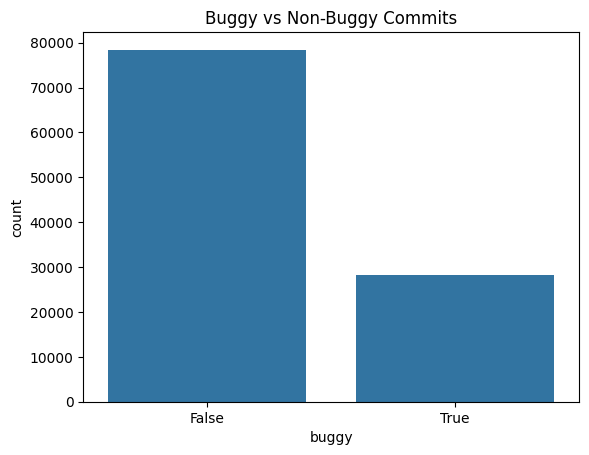

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['buggy'])

plt.title("Buggy vs Non-Buggy Commits")
plt.show()

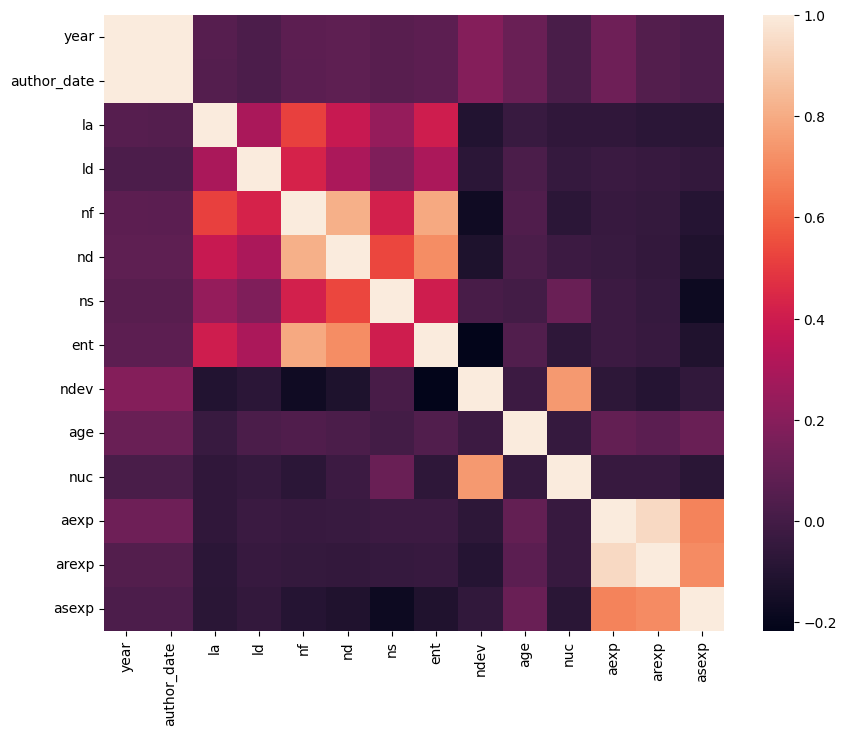

In [14]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=False)

plt.show()

In [15]:
df = df.fillna(0)

In [16]:
save_path = "/content/drive/MyDrive/JIT_bug_prediction/data/processed.csv"

df.to_csv(save_path, index=False)